# 층화추출법
- 통계학에서 층화추출법은 모집단을 먼저 중복되지 않도록 층을 나눈 다음 각 층에서 표본을 추출하는 방법
- 분류 문제의 데이터를 분할할때 train_test_split함수에서 stratify인자에 범주를 입력하여 사용
    - 미적용시 데이터 표본의 문제로 인해 결과가 안 좋을 수 있음
- stratify인자로 인해 원본 데이터셋의 범주 비율과 분할된 데이터셋의 범주 비율을 동일하게 유지해줌

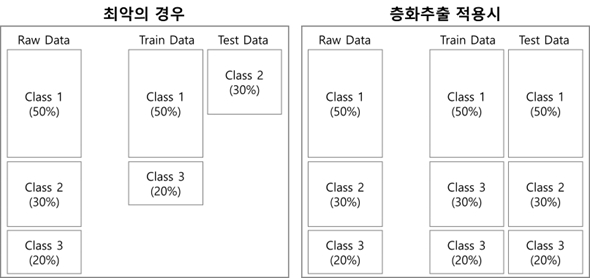

# Decision Tree
- 트리 구조를 이용하여 데이터 사에 존재하는 패턴을 예측가능한 규칙들의 조합으로 나타내는 알고리즘
    - 분류와 회귀 문제에서 모두 사용 가능
- 각 변수의 영역을 재귀적으로 분할하면서 규칙을 생성
    - if-else 형식으로 표현되는 규칙 생성
- 분류의 경우 특성의 영역을 분할하면서 정보 균일도(분류된 세트에 포함된 정보가 비슷한 정도)가 높게 하도록 분할
    - 영역 분할 후 각 영역의 순도 증가 및 불순도 또는 불확실성이 감소하도록 학습
    - 정보 균일도 : Entrophy와 Gini를 이용하여 정보의 균일도를 측정
- 회귀의 경우 잔차 제곱합(RSS)이 최소가 되도록 분할
    

## Tree 구조
- 트리의 정의
    - 한개 이상의 노드로 이루어진 유한집합
    - 나머지 노드들은 n(≥0)개의 분리집합 T1, T2, .., TN으로 분리될 수 있음
    - T1, T2, ..., TN은 각각 하나의 트리가 되며(재귀적 정의) 루트의 부트리(subtree)라고 함
- 주요 용어
    - 노드(node) : 트리의 원소        
    - 간선(edge) : 노드를 연결하는 선, 부모노드와 자식 노드를 연결
    - 루트노드(root node) : 트리의 시작 노드
    - 형제노드(sibling node) : 같은 부모 노드의 자식 노드들
    - 조상노드 : 간선을 따라 루트노드까지 이르는 경로에 이르는 모든 노드들
    - 차수(degree)
        - 노드의 차수 : 노드에 연결된 자식 노드의 수
        - 트리의 차수 : 트리에 있는 노드의 차수 중에서 가장 큰 값
        - 단말노드의 차수 = 0
    - 높이(height, label)
        - 노드의 높이 : 루트에서 노드에 이르는 간선의 수, 노드의 레벨
        - 트리의 높이 : 트리에 있는 노드의 높이 중 가장 큰 값, 최대레벨
        - 루트노드의 높이 = 0

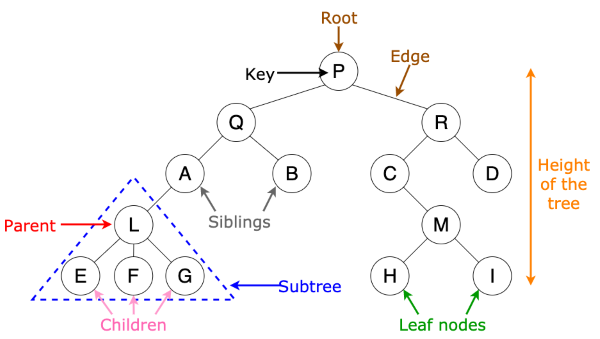

## 정보 균일도(불순도)
- 엔트로피(Entropy)
    - 주어진 데이터 집합의 혼잡도 (값이 작을수록 데이터가 균일)
- 지니 계수(Gini)
    - 주어진 데이터 집합의 불순도 (값이 작을수록 데이터가 균일)
    - Decision Tree에서, 임의로 2개의 데이터를 선택했을 때 서로 다를 확률

Pik => 확률

Ri -> 전체에대한 확률

### 엔트로피(Entropy)
- m개의 레코드가 속하는 A영역에 대한 Entropy <br>
$ Entropy(A) = \sum_{i=1}^{d}(R_i(-\sum_{k=1}^{m}p_{ik}log_2(p_{ik}))$

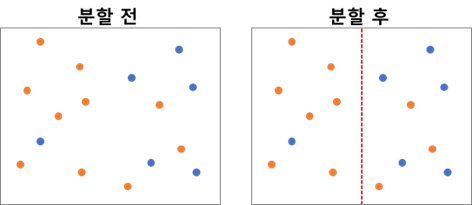

- 분할전 Entropy
    - 주황색 데이터(k=1), 파란색 데이터(k=2) <br>
$ Entropy(A) = -\frac{10}{16}log_2(\frac{10}{16}) -\frac{6}{16}log_2(\frac{6}{16}) ≈ 0.95$
- 분할후 Entropy : 두개의 영역(R1, R2)으로 분할
    - 주황색 데이터(k=1), 파란색 데이터(k=2) <br>
$ Entropy(A) = \frac{8}{16}(-\frac{7}{8}log_2(\frac{7}{8}) -\frac{1}{8}log_2(\frac{1}{8})) + \frac{8}{16}(-\frac{3}{8}log_2(\frac{3}{8}) -\frac{5}{8}log_2(\frac{5}{8})) ≈ 0.75$
- 0.2만큼 엔트로피(불확실성) 감소


### 지니계수(Gini)
- m개의 레코드가 속하는 A영역에 대한 Gini <br>
$Gini(A) = - \sum_{i=1}^{d}(R_i(1-\sum_{k=1}^{m}p_{ik}^2))$

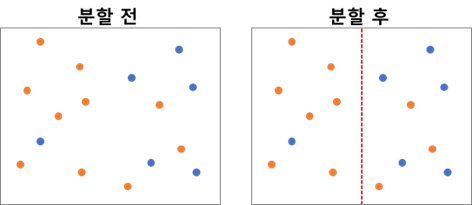

- 분할전 Gini
    - 주황색 데이터(k=1), 파란색 데이터(k=2) <br>
$Gini(A) = 1 -(\frac{10}{16})^2 - (\frac{6}{16})^2  ≈ 0.47$
- 분할후 Gini : 두개의 영역(R1, R2)으로 분할
    - 주황색 데이터(k=1), 파란색 데이터(k=2) <br>
$Gini(A) = \frac{8}{16}(1 - (\frac{7}{8})^2 - (\frac{1}{8})^2) + \frac{8}{16}(1 - (\frac{3}{8})^2 - (\frac{5}{8})^2) ≈ 0.34$
- 약 0.13만큼 불순도 감소


최대한 순도가 높게 데이터를 분할해보자는게 목적

### 엔트로피 vs. 지니
- 범주가 2개일 때 한쪽 범주에 속한 비율에 따른 변화 그래프

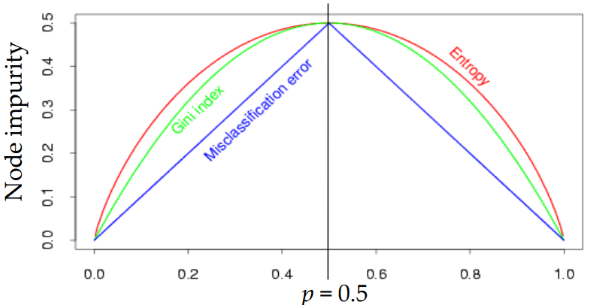

- 두 범주가 각각 반반씩 섞여있는 경우 불순도가 최대이며, 한 범주로만 구성되어 있는 경우 불순도가 최소인 것을 확인

밑에 강수확률을 나눌 때 ex)50 이상이면 true 이하이면 false로 나눌 수 있다. <br>
컨디션 또한 bad 만 false로 둘 수 있다.

## Classifier Tree 동작과정
- 날씨맑음, 비예보, 컨디션에 따른 학교 출석여부를 Decision Tree를 이용하여 분류 <br>
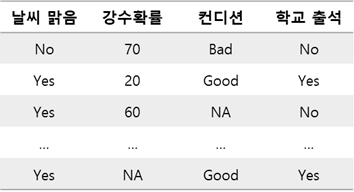
- 분류기준 생성
    - 이진 범주형 특성이기 때문에 True, False로 구분 가능
        - 연속형 특성인 경우 특성의 값을 분할
    - 각 노드의 데이터 개수는 [Yes, No]로 표현
        - 결과 노드의 과반 범주로 예측됨 <br>
    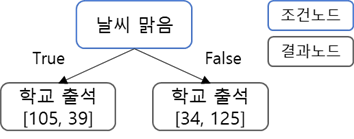
- 분류 기준에 따른 결과 값을 다음과 같이 얻을 수 있음
    - NA는 제외하고 계산 <br>

    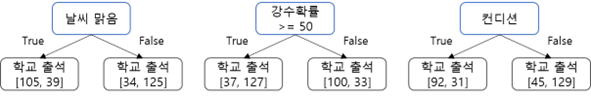
- 가장 좋은 분류 결과를 가지는 노드부터 Tree에 추가
    - 좋은 분류 결과를 가지는 노드를 Root 노드로 지정
        - 3개의 특성 모두 결과 노드가 서로 다른 범주가 과반이기 때문에 모두 괜찮은 결과라고 할 수 있음
        - 만약 성별 특성으로 분할 후 결과 노드가 [62, **82**], [75, **84**]로 분할되었다면 심장 질병이 없는 범주가 두 결과 노드의 과반이기 때문에 좋은 분류 기준이 아님
    - 좋은 분류 결과를 계산하기 위해서 불순도를 계산
        - Gini 불순도 계산
            - 결과노드의 값을 이용하여 Gini 불순도 계산
            - 결과노드의 데이터 개수가 일치하지 않기 때문에 평균 가중치를 이용하여 최종 불순도 계산
            - 예시<br>
$left = 1 - (\frac{105}{105+39})^2 - (\frac{39}{105+39})^2 = 0.395$
$rigit = 1 - (\frac{34}{34+125})^2 - (\frac{125}{34+125})^2 = 0.336$
$Weighted Gini = (\frac{144}{144+159}) * 0.395 + (\frac{159}{144+159}) * 0.336 = 0.364$
            - 날씨 맑음(0.364), 강수확률(0.360), 컨디션(0.381)의 불순도 값을 계산할 수 있고, 강수확률의 특성을 이용하여 불순도가 가장 낮으므로, 강수확률 노드를 Root 노드로 지정
        - Gini불순도 재계산
            - 가장 좋은 기준인 강수확률의 특성값이 True에 해당하는 데이터를 기존의 특성을 다시 조건을 생성하여 불순도 계산 <br>
            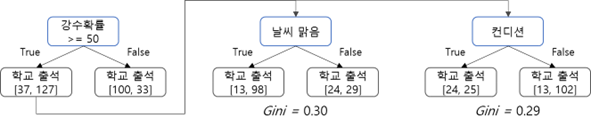
        - 가장 좋은 분류 결과인 컨디션 특성을 이용하여 Tree에 추가 <br>
        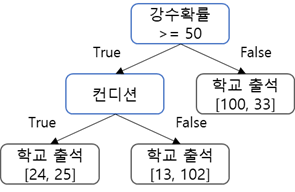
        - 남아있는 특성으로 조건 생성
            - 만약 불순도가 더 커지는 경우 조건을 생성하지 않음
        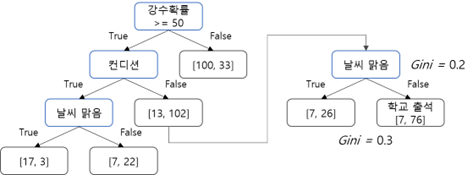
    - 최종 학습 결과
        - 이진특성, 연속형특성외에도 범주형 특성도 분할 가능
            - 예) 음주등급(심각, 보통, 좋음)이 보통 또는 좋음인 경우 True, 심각인 경우 False로 분류
        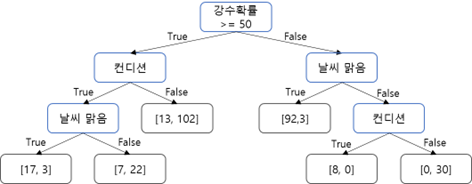

    - 새로운 데이터 예측

    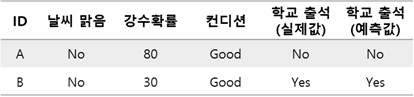

    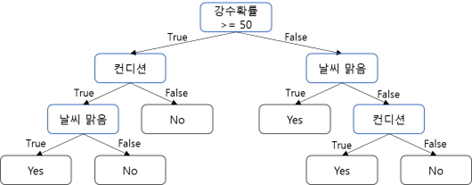


A와 B에 대해 볼 때 강수확률 컨디션 날씨에 대해 순서대로 보며 예측

### [예제] 와인의 품종에 대한 이진분류
- [와인데이터](https://drive.google.com/file/d/1aRGxy-a4Ia6sRe4nBPY_HCIvXFVqTnl-/view?usp=drive_link)
- 데이터 추출 및 분할
    - 분할시 stratify를 사용하여 범주별 비율을 유지한 상태로 train과 test의 범주별 비율 유지

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
wine = pd.read_csv('/content/drive/MyDrive/wine_data.csv')
X_data = wine.drop(columns='class')
y_data = wine['class']
wine['class'].value_counts(0) # 각 클래스별로 몇개씩 있는지 알아볼 수 있다.

,count
class,
1,71
0,59


In [16]:
# 데이터 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_data,
                                                    y_data,
                                                    stratify = y_data, # 어떤걸 기준으로 층화추출할건지
                                                    test_size = 0.3,
                                                    random_state=0)

In [21]:
# 모델 학습 및 평가
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)

print('Train score', dt.score(X_train, y_train))
print('Test score', dt.score(X_test, y_test))

# 트리모델은 과대적합이 될 가능성이 크다
# dt = DecisionTreeClassifier() 이때 인자들로 제어해주면 조절이 가능하다
# 밑의 모델 복잡도 케어에서 볼 수 있다.

Train score 1.0
Test score 0.9487179487179487


DecisionTreeClassifier에서<br>
random_state 인자 <br>
모델을 학습할 때 랜덤 샘플링을 가져간다 그래서 분할을 만드는데 있어 랜덤으로 데이터 샘플을 가져간다 default가 None으로 되어있기 때문에 같은 데이터더라도 수치가 다를 수 있다.

In [18]:
# 어떤 특성이 얼마나 모델에 영향을 끼치는지 알수 있다
# 불순도를 기반으로 계산한다
# 총합은 1으로 얼마나 중요도 확인이 가능하다.

- 학습된 모델에 `feature_importances_`속성을 통해 각 특성의 중요도 조회
    - Tree 계열 모델에서 사용가능
    - 불순도를 기반으로 계산 (정규화되었기 때문에 총합은 1)

In [22]:
# 와인데이터의 특성별 중요도
dt.feature_importances_
# 처음과 마지막이 중요하다.특히 마지막.

array([0.11049201, 0.05918699, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.830321  ])

<Axes: >

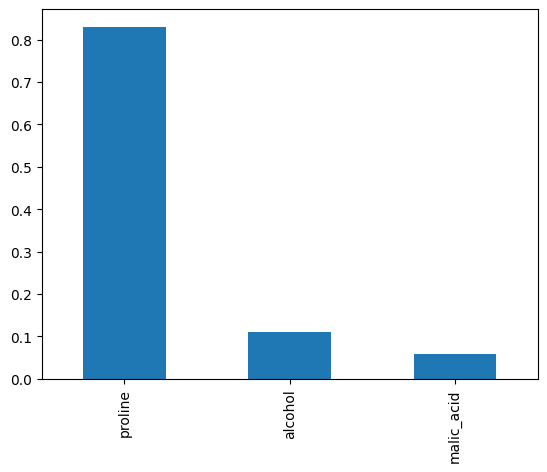

In [23]:
# 특성 중요도 시각화(중요도가 0인 특성 제외)
import matplotlib.pyplot as plt

fi = pd.Series(dt.feature_importances_, index=X_data.columns)
fi[fi!=0].sort_values(ascending=False).plot(kind='bar')

# 클래스를 분류하는데 있어 proline이 중요한 데이터라는 것을 알 수 있다.

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html#sklearn.tree.DecisionTreeClassifier

- 모델 복잡도 제어
    - Tree 계열 모델은 쉽게 과대적합되는 경향이 있어 parameter tuning이 매우 중요함
    - 가장 간단한 방법은 Tree가 너무 깊어지지 않도록 트리의 깊이(max_depth)를 제어
    - 이외에도 노드를 분할을 위한 최소 샘플수(min_sample_split), leaf 노드에 필요한 최소 샘플수(min_samples_leaf), 최대 특성수(max_features), 트리가 가질 수 있는 최대 leaf 노드 수(max_leaf_nodes)를 지정 가능
    - 파라미터별 일반화 관계 <br>
    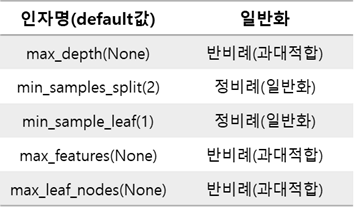

과대적합 가능성이 높을 수록 일반화의 가능성이 적어짐

In [26]:
# max_depth = 3
dt3 = DecisionTreeClassifier(max_depth=3, random_state=0)
dt3.fit(X_train, y_train)
print('Train Score', dt3.score(X_train,y_train))
print('Test Score', dt3.score(X_test,y_test))

Train Score 1.0
Test Score 0.9487179487179487


In [27]:
# max_depth = 5
dt5 = DecisionTreeClassifier(max_depth=5, random_state=0)
dt5.fit(X_train, y_train)
print('Train Score', dt5.score(X_train,y_train))
print('Test Score', dt5.score(X_test,y_test))

Train Score 1.0
Test Score 0.9487179487179487


In [ ]:
# 결과가 max_depth=3, 5 모두 동일
# 왜 동일하게 나왔는지는 시각화를 통해 볼 수 있다.

- Tree 시각화
    - Tree 계열은 쉽게 시각화할 수 있어 비전문가도 이해하기 쉬움
    - scikit-learn에서 Graphviz형식의 구조로 저장 가능

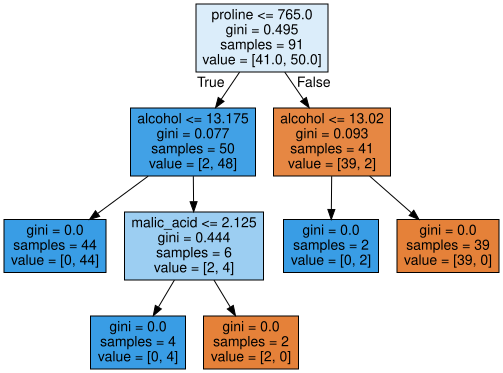

In [29]:
# tree를 시각화하여 이미지 저장
from sklearn.tree import export_graphviz
export_graphviz(dt, out_file='dt.dot',
                feature_names=X_data.columns,
                impurity=True, filled=True)
# 저장된 이미지 확인
import graphviz
with open('dt.dot') as f :
    dot_graph = f.read()
graphviz.Source(dot_graph)

# 파란색 : class1 쪽 /주황색: class0 / 하늘색 : 분류 어려운

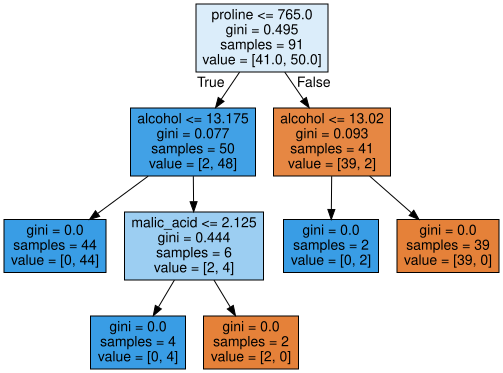

In [30]:
# tree를 시각화하여 이미지 저장
from sklearn.tree import export_graphviz
export_graphviz(dt3, out_file='dt3.dot',
                feature_names=X_data.columns,
                impurity=True, filled=True)
# 저장된 이미지 확인
import graphviz
with open('dt3.dot') as f :
    dot3_graph = f.read()
graphviz.Source(dot3_graph)

# 위와 동일하다
# value의 값 한쪽이 0이면 분리 못함

- Tree 시각화 결과
    - Tree의 최대 깊이가 3을 넘지 않는 것을 확인
    - Tree의 leaf노드는 분류결과이기 때문에 max_depth를 3으로 설정하는 경우 최대 7개의 조건을 만들수 있음

In [ ]:
# max_depth : leafnode 제외

## Regression Tree
- 연속형 레이블을 가지는 데이터가 비선형인 경우 Linear Model사용 시 성능이 좋지 않음
- 이러한 경우 Regression Tree를 이용할 수 있음
    - Regression Tree는 Decision Tree의 회귀모델
- Regression Tree는 분할기준을 이용하여 각 영역의 평균값을 예측결과로 생성
    - 계단 형태의 예측결과를 생성

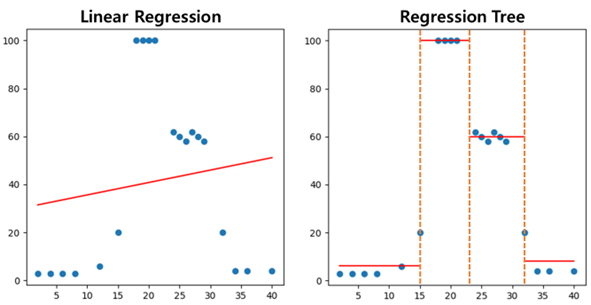

###[예제] 원료투입량에 따른 생산율 예측

- 원료투입량에 따른 생산율을 Regression Tree를 이용하여 예측

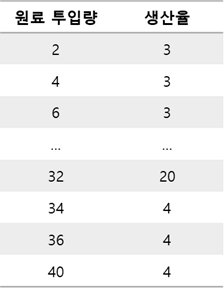
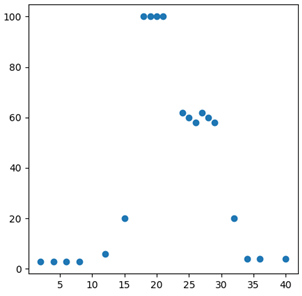    
- 분할 기준 생성 과정
    - 분할 기준을 생성하기 위해 가장 간단한 방법은 데이터를 2개의 그룹으로 만드는 것
        - 데이터를 순서대로 분할하여 기준을 찾아감
    - 순서대로 2개의 학습데이터를 선정 후 평균값을 계산하여 분할기준으로 지정
    - 지정된 기준으로 데이터를 분할하여 분할된 결과의 잔차제곱합을 계산
    - 잔차제곱합의 변화를 통해 잔차 제곱합이 가장 낮은 기준값을 Root 노드로 지정
    - 이후 분할된 영역의 데이터만 이용하여 잔차제곱합을 계산하여 가장 낮은 값을 기준으로 분할 반복 수행
    - 학습 결과 과대적합이 발생한 것을 확인 가능

    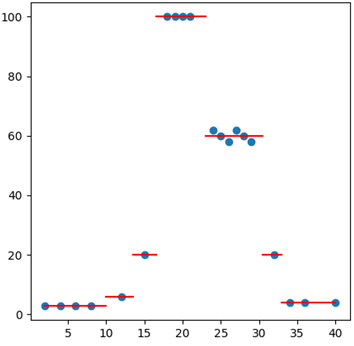

- Regression Tree의 경우 과대적합될 가능성이 매우 높음
- 불필요한 조건을 제거함으로써 모델을 개선할 수 있음
- 현재 학습된 Regression Tree의 결과는 다음과 같음

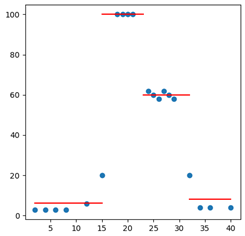
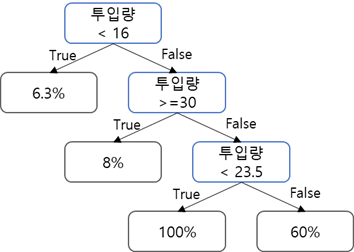

- Regeression Tree 가지치기(Pruning)
    - 평가데이터 예측시 특정 데이터는 잔차가 적은 것을 확인할 수 있지만 그렇지 않은 구간도 존재
    - 가지치기(분류기준 제거)를 한다면 더 좋은 평가데이터 결과를 얻을 수 있음
        - 투입량이 23.5 미만 기준 제거
    
    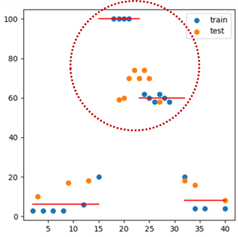
    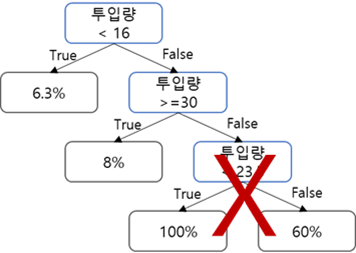

    - 학습데이터의 잔차는 증가하지만 평가데이터 잔차는 감소 ⇒ 과대적합 현상이 개선
    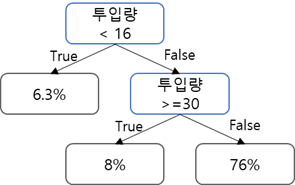

    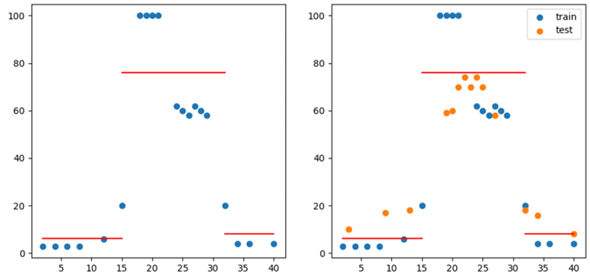

    - 과도한 가지치기를 수행할 경우 모델의 성능 하락
    - 잔자 제곱합 계산을 통해 적절한 모델을 정할 수 있음 (Cost Complexity Pruning)

    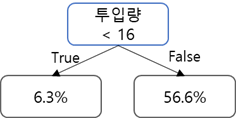
    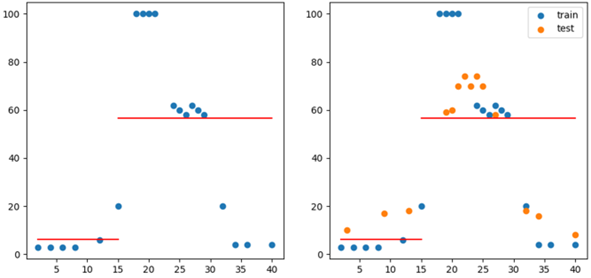

### Cost Complexity Pruning
- 각 모델별 잔차 제곱합을 계산 후 가장 좋은 모델 선정 <br>
$\sum_{i=1}^{n}(실제값 - 예측값)^2$

- Depth = 3 <br>
$\sum_{i=1}^{n}(생산율 - 예측값)^2 = 440.94$

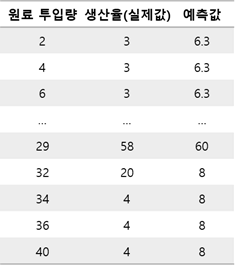
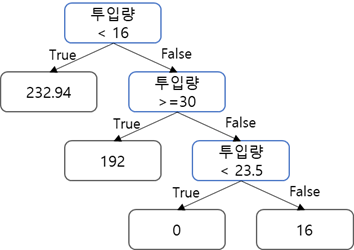

- Depth = 2 <br>
$\sum_{i=1}^{n}(생산율 - 예측값)^2 = 4280.94$

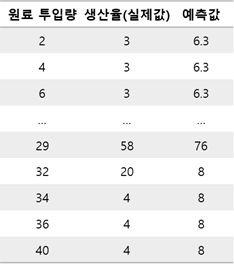
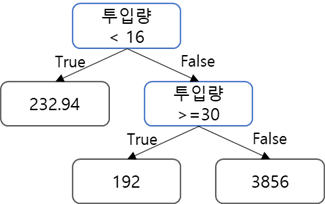

- 가지치기가 진행될수록 잔차제곱합이 커지기 때문에 가지치기가 일어나지 않음
- Tree Complexcity Penalty를 부여하여 적절한 모델 선택
    - 예) 각 leaf 노드당 10000점 부여

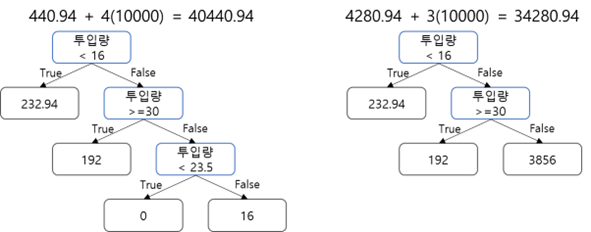

## Decision Tree 장단점
- 장점
    - 모델이 만든 기준과 결과를 해석하고 이해하기 쉬움
    - 자료를 가공할 필요가 거의 없으며, 범주형 및 연속형 특성 모두에 적용 가능
- 단점
    - 트리의 깊이를 제한하지 않는다면 사용할 수 있는 조건 노드가 많아지기 때문에 과대적합 발생가능성이 높음
    - 재귀적으로 분할 기준을 만들기 때문에 계산량이 많을 수 있음
    - 여러개의 결정트리를 만들어 가장 좋은 특성을 통계내어 최적의 결정트리를 찾을 수 있음
    - 데이터가 수직 또는 수평적으로 구분되지 못할 때 결과가 나빠짐

###[예제]당뇨병 데이터 예측

In [31]:
# 데이터 추출 및 분할
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
diabetes = load_diabetes()

X_train,X_test,y_train,y_test = train_test_split(diabetes.data,
                                                 diabetes.target,
                                                 test_size=0.3,
                                                 random_state=0)

In [45]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor()
dtr.fit(X_train,y_train)

print("Train Score", dtr.score(X_train,y_train))
print("Test Score", dtr.score(X_test,y_test))

Train Score 1.0
Test Score -0.21910242922334833


In [46]:
dtr3 = DecisionTreeRegressor(max_depth=3)
dtr3.fit(X_train,y_train)

print("Train Score", dtr3.score(X_train,y_train))
print("Test Score", dtr3.score(X_test,y_test))

Train Score 0.5744216142994143
Test Score 0.18816346294107056


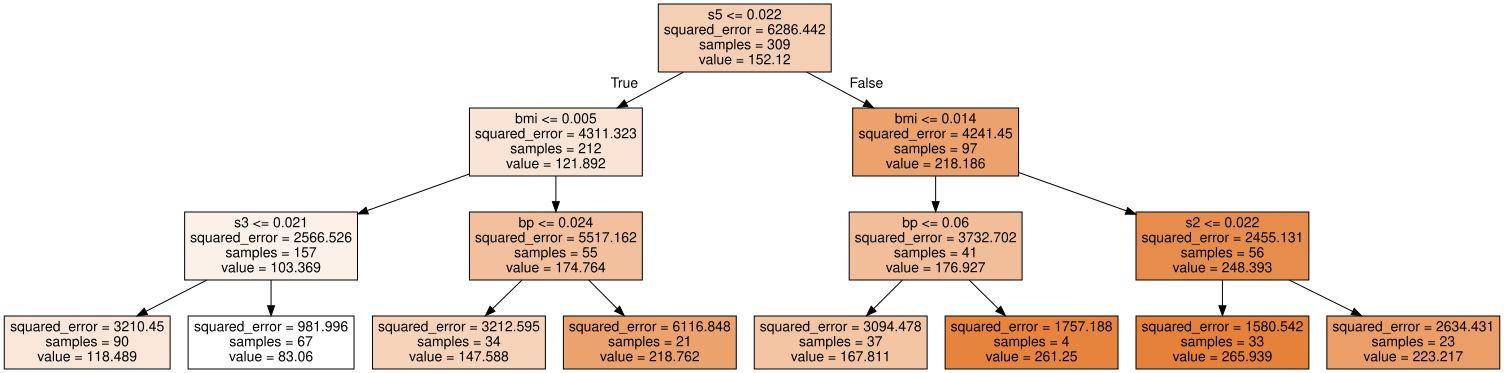

In [47]:
# 트리 이미지 확인
from sklearn.tree import export_graphviz
import graphviz

export_graphviz(dtr3, out_file='dtr3.dot',
                feature_names=diabetes.feature_names,
                impurity=True, filled=True)

with open('dtr3.dot', encoding='utf-8') as f :
    dot_graph=f.read()

graphviz.Source(dot_graph)
# 진할수록 value 높
# 마지막 흰색 예측값 83.06
# s3 <= 0.021 & bmi <= 0.005 & s5 <= 0.02 (갈림길 맨 윗줄 보면)
# : 예측값 value=83.06

In [50]:
# cost comlexity pruning 값 조정
dtr_p = DecisionTreeRegressor(ccp_alpha=100)
dtr_p.fit(X_train,y_train)

print("Train Score", dtr_p.score(X_train,y_train))
print("Test Score", dtr_p.score(X_test,y_test))

Train Score 0.5995585053140943
Test Score 0.18357829297908568


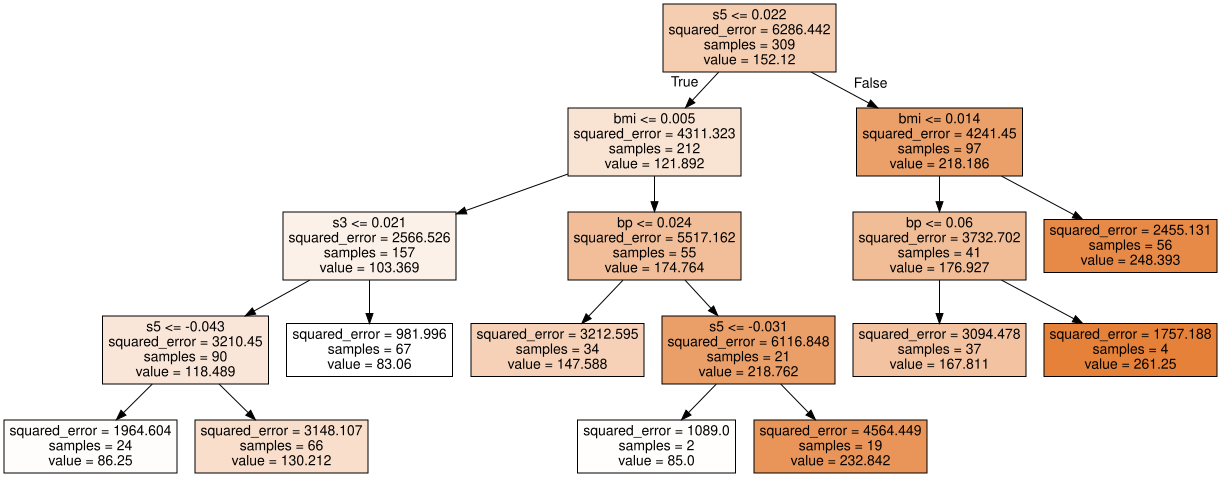

In [ ]:
export_graphviz(dtr_p, out_file='dtr_p.dot',
                feature_names=diabetes.feature_names,
                impurity=True, filled=True)

with open('dtr_p.dot', encoding='utf-8') as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

# [실습1] 분류문제
- 유방암데이터를 활용하여 이진 분류
- depth를 None으로 지정하여 중요한 특성이 무엇인지 확인(시각화)
- max_depth를 3,4 5로 변경하여 어떠한 tree가 나오는지 시각화하고, 어떤 모델이 가장 좋은지 확인

In [1]:
from sklearn.datasets import load_breast_cancer
cancer = load_breast_cancer()

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(cancer.data,
                                                 cancer.target,
                                                 stratify = cancer.target,
                                                 test_size=0.3,
                                                 random_state=0)

In [3]:
# Tree 분류 모델 학습 및 평가
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=0)
dtc.fit(X_train, y_train)

print('Train score', dtc.score(X_train, y_train))
print('Test score', dtc.score(X_test, y_test))

Train score 1.0
Test score 0.9064327485380117


In [4]:
dtc.feature_importances_

array([0.        , 0.06611362, 0.00896396, 0.        , 0.01924893,
       0.        , 0.00264242, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.0104381 , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.80028115, 0.        , 0.0103898 ,
       0.01766415, 0.00349669, 0.04193685, 0.        , 0.01882432])

<Axes: >

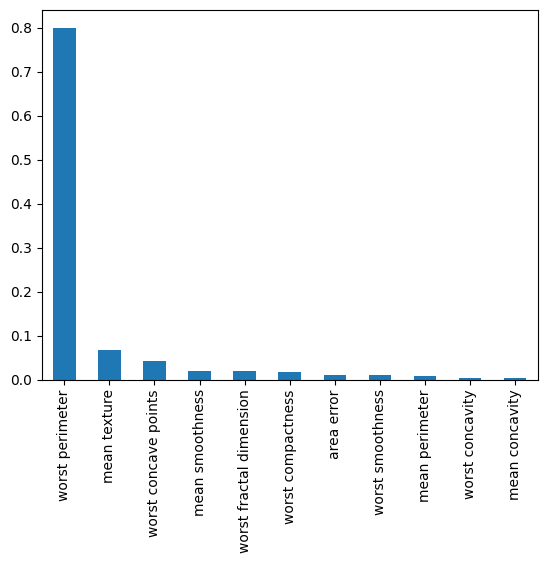

In [5]:
# 특성 중요도 시각화(중요도가 0인 특성 제외)
import matplotlib.pyplot as plt
import pandas as pd
fic = pd.Series(dtc.feature_importances_, index=cancer.feature_names)
fic[fic!=0].sort_values(ascending=False).plot(kind='bar')

In [7]:
cancer.data.shape

(569, 30)

In [8]:
# None일때의 depth의 크기
dtc.tree_.max_depth

6

In [6]:
# max_depth = 3
dt3 = DecisionTreeClassifier(max_depth=3, random_state=0)
dt3.fit(X_train, y_train)
print('Train Score', dt3.score(X_train,y_train))
print('Test Score', dt3.score(X_test,y_test))
print("--------------------------")
# max_depth = 4
dt4 = DecisionTreeClassifier(max_depth=4, random_state=0)
dt4.fit(X_train, y_train)
print('Train Score', dt4.score(X_train,y_train))
print('Test Score', dt4.score(X_test,y_test))
print("--------------------------")
# max_depth = 5
dt5 = DecisionTreeClassifier(max_depth=5, random_state=0)
dt5.fit(X_train, y_train)
print('Train Score', dt5.score(X_train,y_train))
print('Test Score', dt5.score(X_test,y_test))

Train Score 0.9798994974874372
Test Score 0.9005847953216374
--------------------------
Train Score 0.9899497487437185
Test Score 0.9064327485380117
--------------------------
Train Score 0.9974874371859297
Test Score 0.9122807017543859


In [10]:
# 위와 같음 반복문으로 출력
max = [3,4,5]
for m in max:
    dt = DecisionTreeClassifier(random_state=0, max_depth=m)
    dt.fit(X_train, y_train)
    print('Max Depth :', m)
    print('Train Score :', dt.score(X_train, y_train))
    print('Test Score :', dt.score(X_test, y_test))

Max Depth : 3
Train Score : 0.9798994974874372
Test Score : 0.9005847953216374
Max Depth : 4
Train Score : 0.9899497487437185
Test Score : 0.9064327485380117
Max Depth : 5
Train Score : 0.9974874371859297
Test Score : 0.9122807017543859


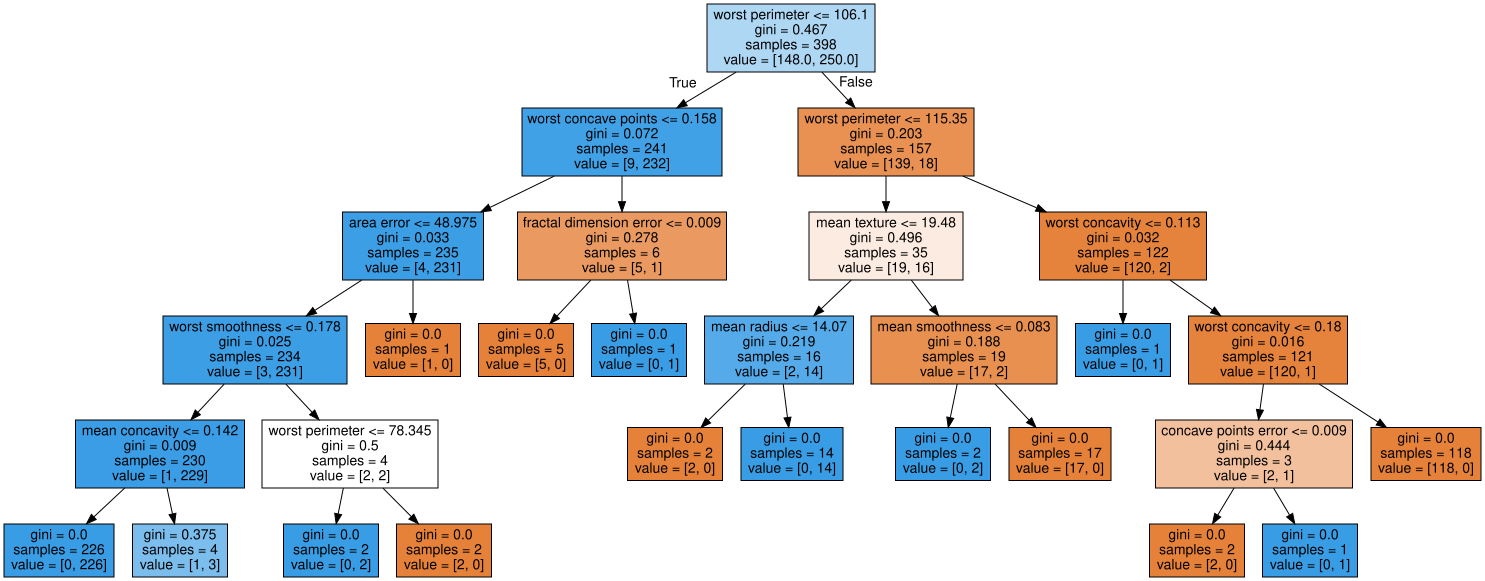

In [11]:
# max depth가 5인 모델에 대해 시각화
from sklearn.tree import export_graphviz
import graphviz

export_graphviz(dt, out_file='dt5.dot',
                feature_names=cancer.feature_names,
                impurity=True, filled=True)

with open('dt5.dot', encoding='utf-8') as f:
    dot_graph = f.read()

graphviz.Source(dot_graph)

#[실습2] 회귀문제
- [보스턴 주택 가격](https://drive.google.com/file/d/17ygxKFk3IyOhe6lIWm1OBqUY6eeDq3I8/view?usp=sharing)데이터를 활용하여 회귀문제
- depth를 None으로 지정하여 중요한 특성이 무엇인지 확인(시각화)
- max_depth를 3, 4, 5로 변경하여 어떤 tree가 만들어지는지 시각화하고, 어떤 모델이 가장 좋은지 확인

In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
boston = pd.read_csv('/content/drive/MyDrive/boston.csv')
X_data = boston.drop(columns=['MEDV'])
y_data = boston['MEDV']

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X_data,
                                                 y_data,
                                                 test_size=0.3,
                                                 random_state=0)

In [17]:
# 모델 학습 및 평가
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state=0)
dtr.fit(X_train, y_train)

print("Depth :", dtr.tree_.max_depth)
print('Train Score:', dtr.score(X_train, y_train))
print('Test Score:', dtr.score(X_test, y_test))

Depth : 17
Train Score: 1.0
Test Score: 0.6835179161458892


In [18]:
# 모델 학습 및 평가
from sklearn.tree import DecisionTreeRegressor
dt3 = DecisionTreeRegressor(max_depth=3, random_state=0)
dt3.fit(X_train, y_train)
print('Train Score', dt3.score(X_train,y_train))
print('Test Score', dt3.score(X_test,y_test))

Train Score 0.8511285677547421
Test Score 0.6628873063238391


In [77]:
dt4 = DecisionTreeRegressor(max_depth=4, random_state=0)
dt4.fit(X_train, y_train)
print('Train Score', dt4.score(X_train,y_train))
print('Test Score', dt4.score(X_test,y_test))

Train Score 0.8994058027243662
Test Score 0.6678638597655544


In [78]:
dt5 = DecisionTreeRegressor(max_depth=5, random_state=0)
dt5.fit(X_train, y_train)
print('Train Score', dt5.score(X_train,y_train))
print('Test Score', dt5.score(X_test,y_test))

Train Score 0.9283020701093933
Test Score 0.700741432004224


<Axes: >

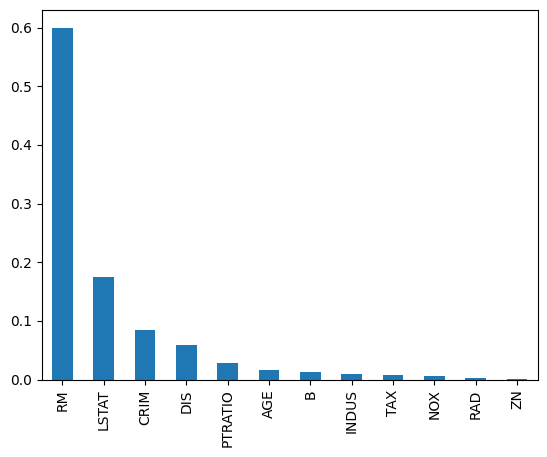

In [ ]:
fir = pd.Series(dtr.feature_importances_, index=X_data.columns)
fir[fir!=0].sort_values(ascending=False).plot(kind='bar')

# RM이 가장 중요

In [20]:
# 어떤 max_depth가 제일 좋을지 확인
import numpy as np
max = np.arange(3,17)
models = []

for m in max:
    dt = DecisionTreeRegressor(random_state=0, max_depth=m)
    dt.fit(X_train, y_train)
    models.append(dt)

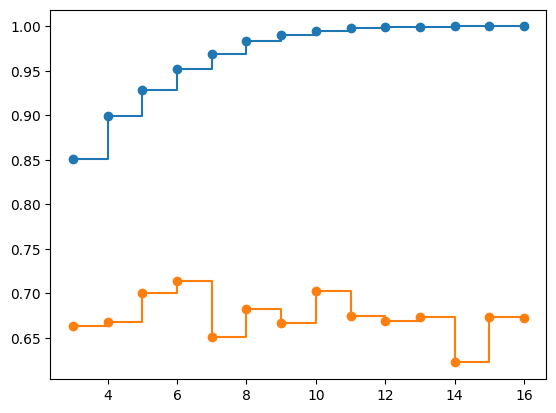

In [21]:
train_scores =[dt.score(X_train, y_train) for dt in models]
test_scores =[dt.score(X_test, y_test) for dt in models]

plt.plot(max, train_scores, label='train', marker = 'o', drawstyle='steps-post')
plt.plot(max, test_scores, label='test', marker = 'o', drawstyle='steps-post')

# 최적은 depth가 6일 때이다.
# 3,4,5 알아봤을 때는 5가 제일 좋다.

- `ccp_alpha` : leaf node 개수에 대한 패널티값
- `cost_complexity_pruning_path` : 최적의 알파값과 불순도에 대한 경로

In [23]:
# 가지치기를 많이 하면 할수록 잔차제곱의 합은 늘어난다
# 그런것들을 방지하기 위해 leafnode의 개수에 대한 패널티값을 주게되면
# 가지치기를 하더라도 잔차제곱(cost)이 줄어드는 방법이 될 수 있다.

# 위의 cost complexity pruning에서
# 각 leaf 노드당 10000점 부여해주는 것은 alpha 값이 10000이었다고 볼 수 있다.

# 가지치기
# 알파를 0으로 둔다는 것은 최대 깊이를 다 가져간다는 것
# 값이 높으면 높을 수록 줄어든다
# 그 값을 주는게 ccp_alpha

# cost_complexity_pruning_path -> 내 가지하나 칠 때 최적의 알파값은 몇이고 그렇게 했을 떄 불순도가 몇인지

path = dtr.cost_complexity_pruning_path(X_train, y_train)
path

# ccp_alpha : 알파값(패널티값) / impurity : 패널티 값에 대한 불순도 이 출력되고 있다.
# 알파값이 커질수록 불순도가 높아질 수 밖에 없다(커지는 것을 확인할 수 있음.)

{'ccp_alphas': array([0.00000000e+00, 1.60574630e-16, 9.63447777e-16, 1.28459704e-15,
        1.28459704e-14, 1.41242938e-05, 1.41242938e-05, 1.41242938e-05,
        1.41242938e-05, 1.41242938e-05, 1.41242938e-05, 1.41242938e-05,
        1.41242938e-05, 1.41242938e-05, 1.41242938e-05, 1.41242938e-05,
        1.41242938e-05, 1.41242938e-05, 1.41242938e-05, 1.41242938e-05,
        1.41242938e-05, 1.41242938e-05, 1.41242938e-05, 1.41242938e-05,
        1.41242938e-05, 1.41242938e-05, 1.41242938e-05, 1.88323917e-05,
        1.88323917e-05, 1.88323917e-05, 1.88323917e-05, 1.88323917e-05,
        4.23728814e-05, 4.23728814e-05, 4.23728814e-05, 4.23728814e-05,
        5.64971751e-05, 5.64971751e-05, 5.64971751e-05, 5.64971751e-05,
        5.64971751e-05, 5.64971751e-05, 5.64971751e-05, 5.64971751e-05,
        5.64971751e-05, 5.64971751e-05, 5.64971751e-05, 5.64971751e-05,
        5.64971751e-05, 5.64971751e-05, 7.53295669e-05, 7.53295669e-05,
        1.15348399e-04, 1.15348399e-04, 1.17702448

In [24]:
# 어떤 알파가 제일 좋은지 그래프를 그려볼 수 있다.
ccp_alphas = path.ccp_alphas[:-1] # 마지막은 모든 노드를 다 삭제하는 경우이니 마지막제외
dts = []
for a in ccp_alphas:
    dt = DecisionTreeRegressor(random_state=0, ccp_alpha=a)
    dt.fit(X_train, y_train)
    dts.append(dt)

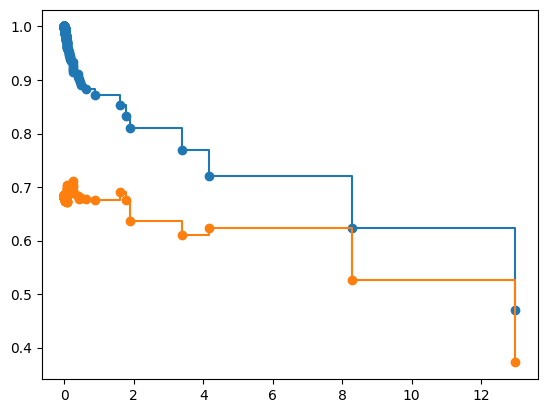

In [ ]:
train_scores =[dt.score(X_train, y_train) for dt in dts]
test_scores =[dt.score(X_test, y_test) for dt in dts]

plt.plot(ccp_alphas, train_scores, label='train', marker = 'o', drawstyle='steps-post')
plt.plot(ccp_alphas, test_scores, label='test', marker = 'o', drawstyle='steps-post')

# 알파가 늘어나면 늘어날수록 score는 떨어진다. 왜냐하면 가지를 많이 치기 때문에!
# alpha 값으로 보았을 때는 2정도 되었을 때 제일 값이 적당하다고 볼 수 있다.